# Cross-Source Knowledge Graph Analysis

Exampls queries and visualizations that are possible because all 15 security data sources are merged into a single graph.

In [1]:
import sys

sys.path.insert(0, "..")

from itertools import combinations

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import PowerNorm

sns.set_theme(style="whitegrid", context="notebook", font_scale=0.95)
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": "#444444",
        "axes.labelcolor": "#222222",
        "xtick.color": "#333333",
        "ytick.color": "#333333",
        "text.color": "#222222",
        "legend.facecolor": "white",
        "legend.edgecolor": "#cccccc",
        "savefig.facecolor": "white",
        "grid.color": "#eeeeee",
        "grid.alpha": 0.7,
    }
)

PASTEL = sns.color_palette("pastel")
MUTED = sns.color_palette("muted")
# Named pastel colors for semantic use
P_RED, P_BLUE, P_GREEN, P_ORANGE, P_PURPLE, P_BROWN, P_PINK, P_GRAY, P_YELLOW, P_CYAN = PASTEL
M_RED, M_BLUE, M_GREEN, M_ORANGE, M_PURPLE, M_BROWN, M_PINK, M_GRAY, M_YELLOW, M_CYAN = MUTED

df = pd.read_parquet("../output/combined.parquet")
df["predicate"] = df["predicate"].astype("category")

_pred_cache: dict[str, pd.DataFrame] = {}


def by_pred(p: str) -> pd.DataFrame:
    if p not in _pred_cache:
        _pred_cache[p] = df[df.predicate == p]
    return _pred_cache[p]


names = by_pred("name")
_name_map = dict(zip(names.subject, names.object, strict=False))


def name_of(entity_id: str, max_len: int = 0) -> str:
    label = _name_map.get(entity_id, entity_id)
    return label[:max_len] if max_len else label


print(f"Loaded {len(df):,} triples")

Loaded 18,057,895 triples


## 1. SSVC Patch Prioritization Matrix

CISA's [SSVC framework](https://www.cisa.gov/stakeholder-specific-vulnerability-categorization-ssvc) (from Vulnrichment) combines exploitation status, automatable assessment, and technical impact into actionable triage decisions. Crosses 140K+ SSVC-enriched CVEs with EPSS and KEV for a multi-signal prioritization view.

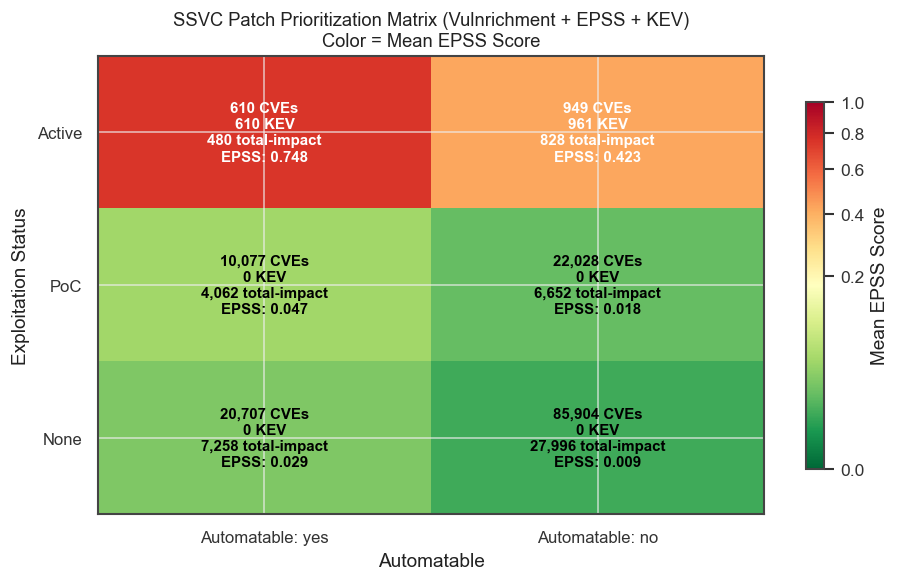

CVEs with SSVC enrichment: 140,303

SSVC Priority Breakdown:
  active  + automatable=yes:    610 CVEs, mean EPSS=0.748, 610 in KEV, 480 total-impact
  active  + automatable=no :    963 CVEs, mean EPSS=0.423, 961 in KEV, 828 total-impact
  poc     + automatable=yes: 10,077 CVEs, mean EPSS=0.047, 0 in KEV, 4,062 total-impact
  poc     + automatable=no : 22,035 CVEs, mean EPSS=0.018, 0 in KEV, 6,652 total-impact
  none    + automatable=yes: 20,714 CVEs, mean EPSS=0.029, 0 in KEV, 7,258 total-impact
  none    + automatable=no : 85,904 CVEs, mean EPSS=0.009, 0 in KEV, 27,996 total-impact


In [2]:
# SSVC decision points from Vulnrichment
ssvc_exploit = by_pred("ssvc-exploitation")[["subject", "object"]].rename(
    columns={"subject": "cve", "object": "exploitation"}
)
ssvc_auto = by_pred("ssvc-automatable")[["subject", "object"]].rename(
    columns={"subject": "cve", "object": "automatable"}
)
ssvc_impact = by_pred("ssvc-technical-impact")[["subject", "object"]].rename(
    columns={"subject": "cve", "object": "impact"}
)

ssvc = ssvc_exploit.merge(ssvc_auto, on="cve").merge(ssvc_impact, on="cve")

# Enrich with EPSS
epss_df = by_pred("epss-score")[["subject", "object"]].rename(
    columns={"subject": "cve", "object": "epss"}
)
epss_df["epss"] = epss_df["epss"].astype(float)
ssvc = ssvc.merge(epss_df[["cve", "epss"]], on="cve", how="left").fillna({"epss": 0})

# Enrich with KEV
rdf = by_pred("rdf:type")
kev_set = set(rdf[rdf.object == "KnownExploitedVulnerability"].subject)
ssvc["in_kev"] = ssvc.cve.isin(kev_set)

# Build priority matrix
matrix = (
    ssvc.groupby(["exploitation", "automatable"])
    .agg(
        count=("cve", "nunique"),
        mean_epss=("epss", "mean"),
        kev_count=("in_kev", "sum"),
        total_impact=("impact", lambda x: (x == "total").sum()),
    )
    .reset_index()
)

# Heatmap: exploitation x automatable, colored by mean EPSS, annotated with counts
exploit_order = ["active", "poc", "none"]
auto_order = ["yes", "no"]

heat_counts = (
    matrix.pivot(index="exploitation", columns="automatable", values="count")
    .reindex(index=exploit_order, columns=auto_order)
    .fillna(0)
    .astype(int)
)
heat_epss = (
    matrix.pivot(index="exploitation", columns="automatable", values="mean_epss")
    .reindex(index=exploit_order, columns=auto_order)
    .fillna(0)
)
heat_kev = (
    matrix.pivot(index="exploitation", columns="automatable", values="kev_count")
    .reindex(index=exploit_order, columns=auto_order)
    .fillna(0)
    .astype(int)
)
heat_impact = (
    matrix.pivot(index="exploitation", columns="automatable", values="total_impact")
    .reindex(index=exploit_order, columns=auto_order)
    .fillna(0)
    .astype(int)
)

# Use a diverging colormap with more contrast across the low end
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(
    heat_epss.values, cmap="RdYlGn_r", aspect="auto", norm=PowerNorm(gamma=0.4, vmin=0, vmax=1)
)

for i, _exploit in enumerate(exploit_order):
    for j, _auto in enumerate(auto_order):
        count = heat_counts.iloc[i, j]
        kev = heat_kev.iloc[i, j]
        impact = heat_impact.iloc[i, j]
        epss_val = heat_epss.iloc[i, j]
        text_color = "white" if epss_val > 0.3 else "black"
        ax.text(
            j,
            i,
            f"{count:,} CVEs\n{kev:,} KEV\n{impact:,} total-impact\nEPSS: {epss_val:.3f}",
            ha="center",
            va="center",
            fontsize=9,
            color=text_color,
            fontweight="bold",
        )

ax.set_xticks([0, 1])
ax.set_xticklabels(["Automatable: yes", "Automatable: no"], fontsize=10)
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(["Active", "PoC", "None"], fontsize=10)
ax.set_xlabel("Automatable")
ax.set_ylabel("Exploitation Status")
ax.set_title(
    "SSVC Patch Prioritization Matrix (Vulnrichment + EPSS + KEV)\nColor = Mean EPSS Score",
    fontsize=11,
)
plt.colorbar(im, ax=ax, label="Mean EPSS Score", shrink=0.8)
plt.tight_layout()
plt.show()

print(f"CVEs with SSVC enrichment: {len(ssvc):,}")
print("\nSSVC Priority Breakdown:")
for exploit in exploit_order:
    for auto in auto_order:
        sub = ssvc[(ssvc.exploitation == exploit) & (ssvc.automatable == auto)]
        if len(sub) > 0:
            kev = sub.in_kev.sum()
            total = (sub.impact == "total").sum()
            print(
                f"  {exploit:7s} + automatable={auto:3s}: {len(sub):>6,} CVEs, "
                f"mean EPSS={sub.epss.mean():.3f}, {kev:,} in KEV, {total:,} total-impact"
            )

## 2. Defensive Gap Analysis

Which heavily-used ATT&CK techniques have the least defensive tooling? Compares group usage against combined detection coverage from CAR, Sigma, D3FEND, ENGAGE, and ATT&CK mitigations.

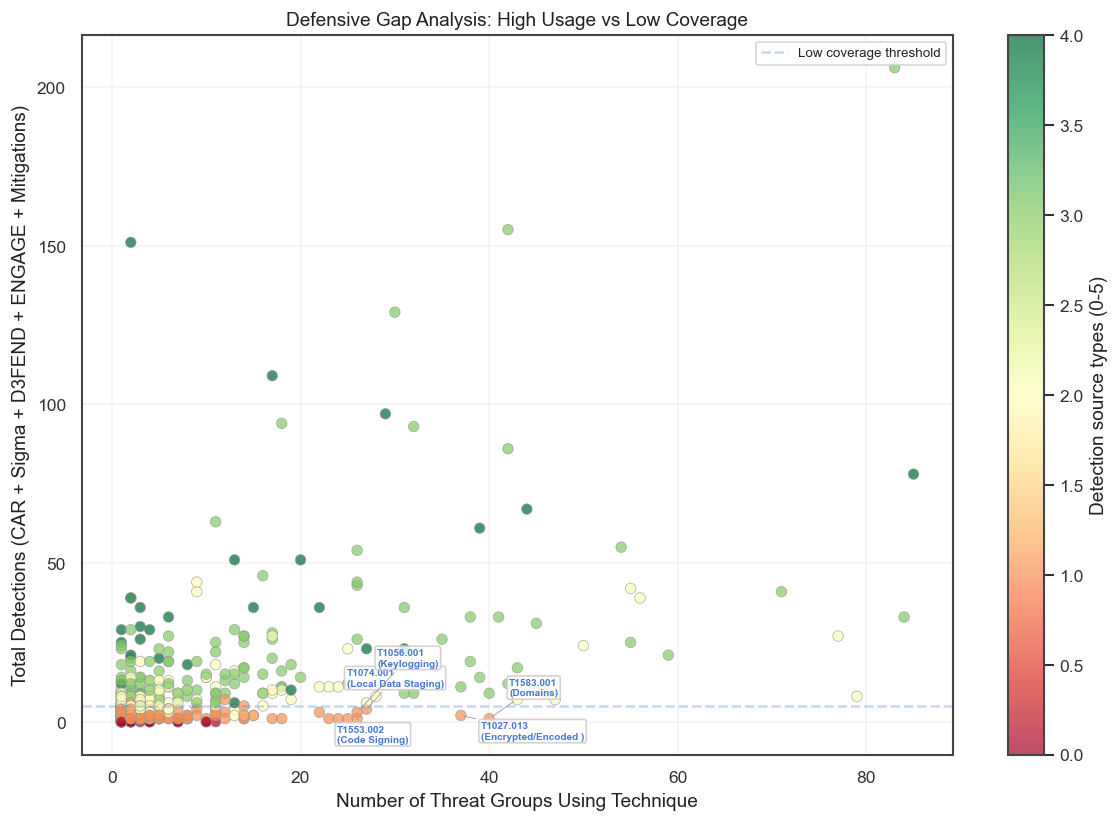

Techniques used by 15+ groups with <=5 detections: 14

Biggest gaps:
  T1583.001 (Domains): 40 groups, 1 detections
  T1027.013 (Encrypted/Encoded File): 37 groups, 2 detections
  T1074.001 (Local Data Staging): 27 groups, 4 detections
  T1056.001 (Keylogging): 26 groups, 3 detections
  T1553.002 (Code Signing): 26 groups, 1 detections
  T1608.001 (Upload Malware): 25 groups, 1 detections
  T1583.006 (Web Services): 24 groups, 1 detections
  T1027.002 (Software Packing): 23 groups, 1 detections
  T1036.004 (Masquerade Task or Service): 22 groups, 3 detections
  T1585.002 (Email Accounts): 18 groups, 1 detections


In [3]:
uses = by_pred("uses")
group_uses = uses[uses.subject.str.startswith("G") & uses.object.str.startswith("T")]
tech_usage = group_uses.groupby("object").subject.nunique().rename("groups_using")

dt = by_pred("detects-technique")
ds = by_pred("detects-subtechnique")
et = by_pred("engages-technique")
mt = by_pred("mitigates")
rt = by_pred("restricts")

rows = []
for tech, group_count in tech_usage.items():
    car = len(
        set(dt[(dt.object == tech) & dt.subject.str.startswith("CAR-")].subject)
        | set(ds[(ds.object == tech) & ds.subject.str.startswith("CAR-")].subject)
    )
    sigma = len(dt[(dt.object == tech) & ~dt.subject.str.startswith("CAR-")].subject.unique())
    d3fend = len(rt[rt.object == tech])
    engage = len(et[et.object == tech].subject.unique())
    mit = len(mt[mt.object == tech].subject.unique())
    source_count = sum([car > 0, sigma > 0, d3fend > 0, engage > 0, mit > 0])
    total_detections = car + sigma + d3fend + engage + mit
    rows.append(
        {
            "technique": tech,
            "groups_using": group_count,
            "source_types": source_count,
            "total_detections": total_detections,
        }
    )

gap_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    gap_df.groups_using,
    gap_df.total_detections,
    c=gap_df.source_types,
    cmap="RdYlGn",
    s=40,
    alpha=0.7,
    edgecolors="#999999",
    linewidths=0.5,
)
plt.colorbar(scatter, ax=ax, label="Detection source types (0-5)")

gaps = gap_df[(gap_df.groups_using >= 15) & (gap_df.total_detections <= 5)]
# Annotate top 5 worst gaps with staggered offsets to avoid overlap
top_gaps = gaps.sort_values("groups_using", ascending=False).head(5)
offsets = [(12, 14), (12, -14), (-12, 14), (12, 28), (-12, -14)]
for idx, (_, row) in enumerate(top_gaps.iterrows()):
    label = name_of(row.technique, 18)
    ox, oy = offsets[idx % len(offsets)]
    ax.annotate(
        f"{row.technique}\n({label})",
        (row.groups_using, row.total_detections),
        fontsize=6,
        color=M_RED,
        fontweight="bold",
        xytext=(ox, oy),
        textcoords="offset points",
        arrowprops=dict(arrowstyle="-", color="#999999", lw=0.5),
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="#cccccc", alpha=0.85),
    )

ax.set_xlabel("Number of Threat Groups Using Technique")
ax.set_ylabel("Total Detections (CAR + Sigma + D3FEND + ENGAGE + Mitigations)")
ax.set_title("Defensive Gap Analysis: High Usage vs Low Coverage")
ax.axhline(y=5, color=M_RED, linestyle="--", alpha=0.3, label="Low coverage threshold")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"Techniques used by 15+ groups with <=5 detections: {len(gaps)}")
if not gaps.empty:
    print("\nBiggest gaps:")
    for _, row in gaps.sort_values("groups_using", ascending=False).head(10).iterrows():
        label = name_of(row.technique)
        print(
            f"  {row.technique} ({label}): "
            f"{row.groups_using} groups, {row.total_detections} detections"
        )

## 3. Kill Chain Tactic Coverage

Detection and defense coverage mapped to ATT&CK tactics (Reconnaissance → Impact). Reveals which kill chain stages have the weakest Sigma/CAR coverage relative to how many APT groups operate there.

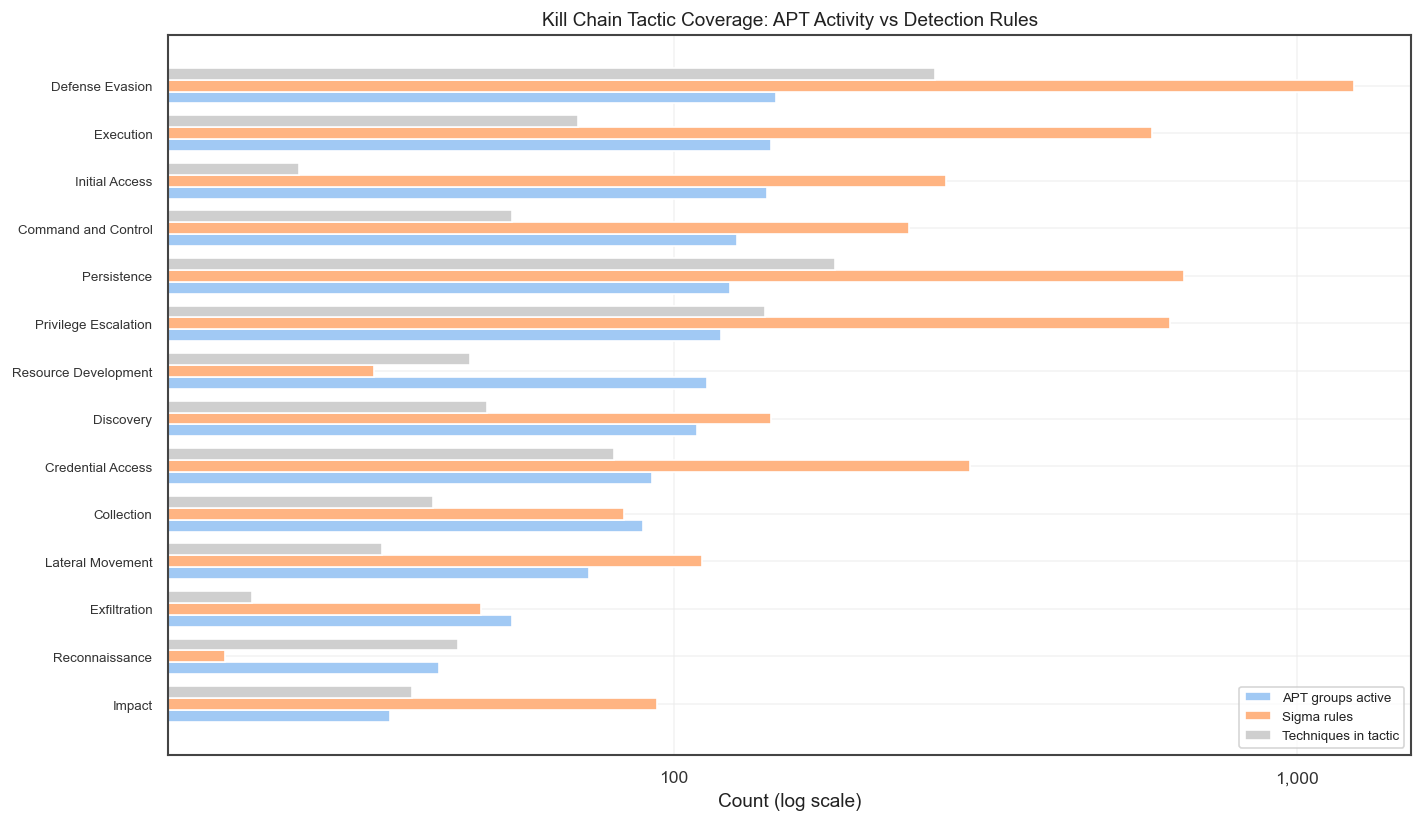

Tactic coverage summary:
  TA0005 (Defense Evasion): 146 groups, 1236 Sigma rules, 44% technique coverage !!!
  TA0002 (Execution): 143 groups, 585 Sigma rules, 43% technique coverage !!!
  TA0001 (Initial Access): 141 groups, 273 Sigma rules, 60% technique coverage 
  TA0011 (Command and Control): 126 groups, 238 Sigma rules, 42% technique coverage !!!
  TA0003 (Persistence): 123 groups, 658 Sigma rules, 44% technique coverage !!!
  TA0004 (Privilege Escalation): 119 groups, 624 Sigma rules, 51% technique coverage 
  TA0042 (Resource Development): 113 groups, 33 Sigma rules, 21% technique coverage !!!
  TA0007 (Discovery): 109 groups, 143 Sigma rules, 60% technique coverage 
  TA0006 (Credential Access): 92 groups, 299 Sigma rules, 50% technique coverage 
  TA0009 (Collection): 89 groups, 83 Sigma rules, 54% technique coverage 
  TA0008 (Lateral Movement): 73 groups, 111 Sigma rules, 47% technique coverage !!!
  TA0010 (Exfiltration): 55 groups, 49 Sigma rules, 43% technique coverage 

In [4]:
# Technique → tactic mapping (Enterprise ATT&CK only, exclude ATLAS duplicates)
bt = by_pred("belongs-to-tactic")[["subject", "object"]].rename(
    columns={"subject": "technique", "object": "tactic"}
)
bt = bt[bt.tactic.str.startswith("TA")]  # Enterprise ATT&CK tactics only

# Group → technique
uses = by_pred("uses")
group_tech = uses[uses.subject.str.startswith("G") & uses.object.str.startswith("T")]

# Sigma → technique
dt = by_pred("detects-technique")
sigma_tech = dt[~dt.subject.str.startswith("CAR-")][["subject", "object"]].rename(
    columns={"subject": "sigma", "object": "technique"}
)

# Per tactic: techniques, group usage, sigma coverage
tactic_stats = []
for tactic in bt["tactic"].unique():
    techs = set(bt[bt.tactic == tactic].technique)
    groups_using = group_tech[group_tech["object"].isin(techs)].subject.nunique()
    sigma_rules = sigma_tech[sigma_tech.technique.isin(techs)].sigma.nunique()
    techs_with_sigma = sigma_tech[sigma_tech.technique.isin(techs)].technique.nunique()
    label = name_of(tactic)
    tactic_stats.append(
        {
            "tactic": tactic,
            "name": label,
            "techniques": len(techs),
            "groups": groups_using,
            "sigma_rules": sigma_rules,
            "techs_with_sigma": techs_with_sigma,
            "coverage_pct": 100 * techs_with_sigma / len(techs) if techs else 0,
        }
    )

tdf = pd.DataFrame(tactic_stats).sort_values("groups", ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
y = np.arange(len(tdf))
w = 0.25

ax.barh(y - w, tdf.groups, w, color=P_RED, edgecolor="white", label="APT groups active")
ax.barh(y, tdf.sigma_rules, w, color=P_BLUE, edgecolor="white", label="Sigma rules")
ax.barh(y + w, tdf.techniques, w, color=P_GRAY, edgecolor="white", label="Techniques in tactic")

labels = [row["name"] for _, row in tdf.iterrows()]
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("Count (log scale)")
ax.set_xscale("log")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}" if x >= 1 else ""))
ax.set_title("Kill Chain Tactic Coverage: APT Activity vs Detection Rules")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

print("Tactic coverage summary:")
for _, row in tdf.sort_values("groups", ascending=False).iterrows():
    gap = "!!!" if row.coverage_pct < 50 else ""
    print(
        f"  {row.tactic} ({row['name'][:25]}): {row.groups} groups, "
        f"{row.sigma_rules} Sigma rules, {row.coverage_pct:.0f}% technique coverage {gap}"
    )

## 4. KEV Remediation Urgency vs Detection Readiness

Which overdue KEV items have high exploit probability but poor detection coverage? Traverses KEV → EPSS + CVE → CWE → CAPEC → ATT&CK technique → Sigma rules.

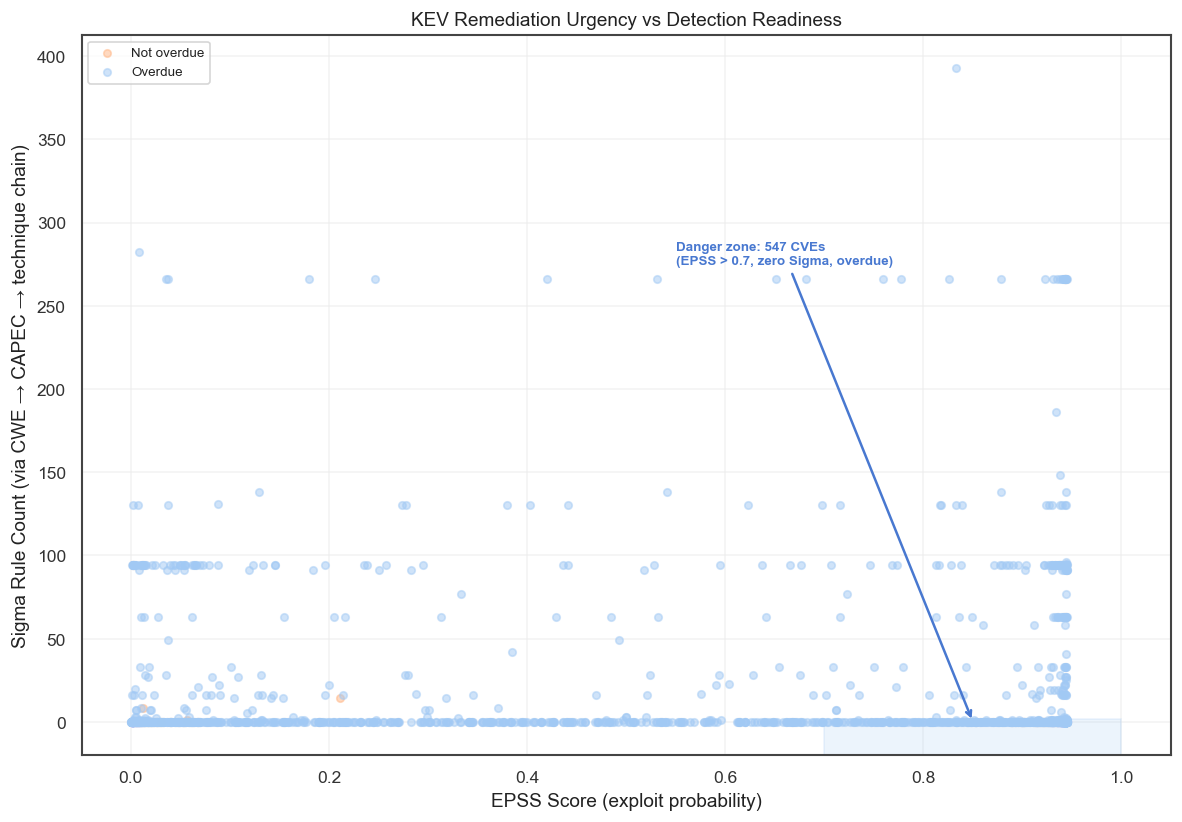

KEV CVEs: 1557, Overdue: 1553
High EPSS (>0.7) + zero Sigma + overdue: 547


In [5]:
kev_due = by_pred("kev-due-date")[["subject", "object"]].rename(
    columns={"subject": "cve", "object": "due_date"}
)
kev_due["due_date"] = pd.to_datetime(kev_due.due_date, errors="coerce")
kev_due["overdue"] = kev_due.due_date < pd.Timestamp.now()

epss_df = by_pred("epss-score")[["subject", "object"]].rename(
    columns={"subject": "cve", "object": "epss"}
)
epss_df["epss"] = epss_df["epss"].astype(float)

# CVE → Sigma rule count via CWE → CAPEC → technique chain
rw = by_pred("related-weakness")
cve_cwe = rw[rw.subject.isin(kev_due.cve) & rw.object.str.startswith("CWE-")][
    ["subject", "object"]
].rename(columns={"subject": "cve", "object": "cwe"})
cwe_capec = by_pred("related-attack-pattern")[["subject", "object"]].rename(
    columns={"subject": "cwe", "object": "capec"}
)
capec_tech = by_pred("maps-to-technique")[["subject", "object"]].rename(
    columns={"subject": "capec", "object": "technique"}
)
dt = by_pred("detects-technique")
sigma_tech = dt[~dt.subject.str.startswith("CAR-")][["subject", "object"]].rename(
    columns={"subject": "sigma", "object": "technique"}
)

cve_sigma = (
    cve_cwe.merge(cwe_capec, on="cwe")
    .merge(capec_tech, on="capec")
    .merge(sigma_tech, on="technique")
)
sigma_per_cve = cve_sigma.groupby("cve").sigma.nunique().rename("sigma_count")

kev_full = (
    kev_due.merge(epss_df, on="cve", how="left")
    .merge(sigma_per_cve.reset_index(), on="cve", how="left")
    .fillna({"epss": 0, "sigma_count": 0})
)

fig, ax = plt.subplots(figsize=(10, 7))

not_overdue = kev_full[~kev_full.overdue]
overdue = kev_full[kev_full.overdue]
ax.scatter(
    not_overdue.epss, not_overdue.sigma_count, c=[P_BLUE], s=20, alpha=0.5, label="Not overdue"
)
ax.scatter(overdue.epss, overdue.sigma_count, c=[P_RED], s=20, alpha=0.5, label="Overdue")

danger = kev_full[(kev_full.epss > 0.7) & (kev_full.sigma_count == 0) & kev_full.overdue]
ax.axvspan(0.7, 1.0, ymin=0, ymax=0.05, color=P_RED, alpha=0.2)
ax.annotate(
    f"Danger zone: {len(danger)} CVEs\n(EPSS > 0.7, zero Sigma, overdue)",
    xy=(0.85, 0),
    fontsize=8,
    color=M_RED,
    fontweight="bold",
    xytext=(0.55, kev_full.sigma_count.max() * 0.7),
    arrowprops=dict(arrowstyle="->", color=M_RED, lw=1.5),
)

ax.set_xlabel("EPSS Score (exploit probability)")
ax.set_ylabel("Sigma Rule Count (via CWE → CAPEC → technique chain)")
ax.set_title("KEV Remediation Urgency vs Detection Readiness")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

print(f"KEV CVEs: {len(kev_full)}, Overdue: {kev_full.overdue.sum()}")
print(f"High EPSS (>0.7) + zero Sigma + overdue: {len(danger)}")

## 5. Exploit Weaponization Timeline

How quickly do vulnerabilities get weaponized? Measures the time delta from CVE publication to public exploit (ExploitDB) and to KEV listing, broken down by CWE class.

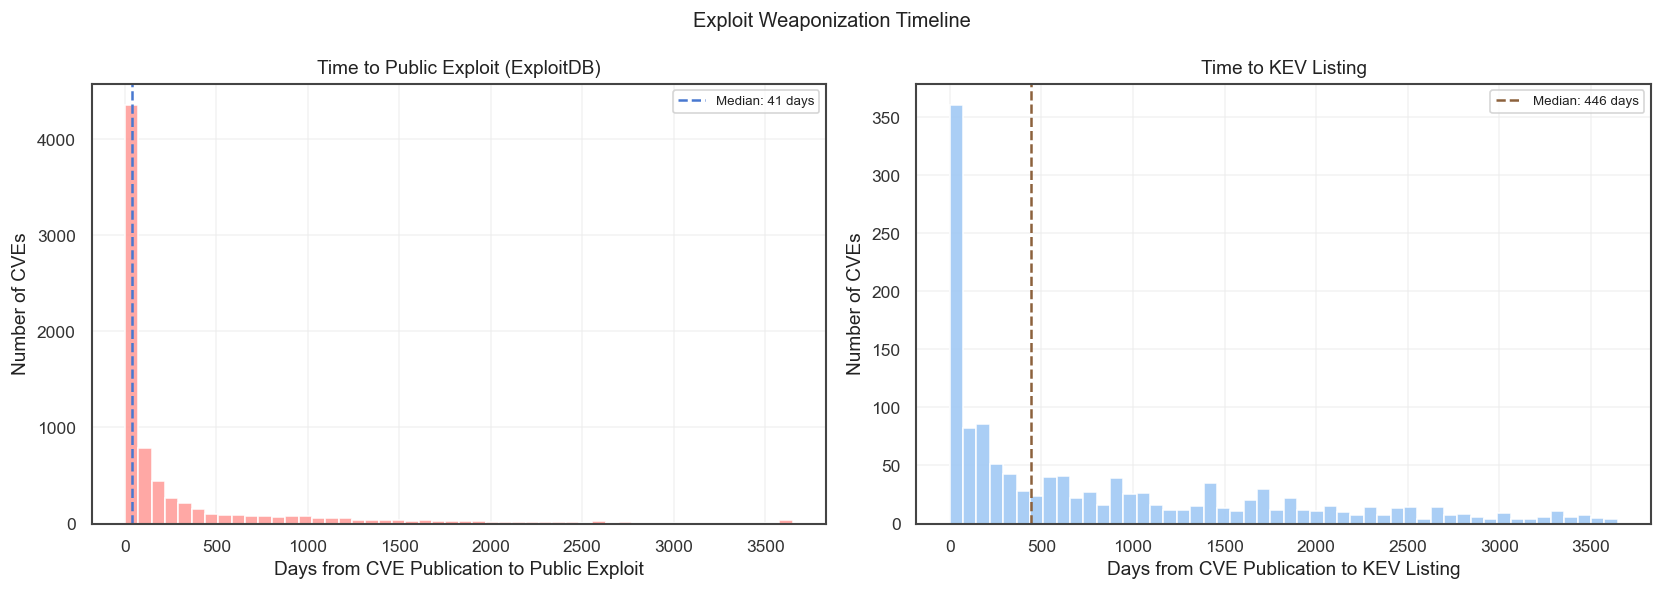

CVEs with exploit timeline data: 7,610
Median time to public exploit: 41 days
Median time to KEV listing: 446 days

Fastest-weaponized CWE classes (min 10 CVEs):
  CWE-122 (Heap-based Buffer Overflow): median 8 days, 10.0 CVEs
  CWE-74 (Improper Neutralization of Special Elements in Output Used by a Downstream Component ('Injection')): median 11 days, 16.0 CVEs
  CWE-78 (Improper Neutralization of Special Elements used in an OS Command ('OS Command Injection')): median 31 days, 47.0 CVEs
  CWE-22 (Improper Limitation of a Pathname to a Restricted Directory ('Path Traversal')): median 34 days, 47.0 CVEs
  CWE-89 (Improper Neutralization of Special Elements used in an SQL Command ('SQL Injection')): median 44 days, 71.0 CVEs
  CWE-502 (Deserialization of Untrusted Data): median 48 days, 25.0 CVEs
  CWE-284 (Improper Access Control): median 53 days, 26.0 CVEs
  CWE-79 (Improper Neutralization of Input During Web Page Generation ('Cross-site Scripting')): median 54 days, 84.0 CVEs
  CWE-11

In [6]:
# CVE publication dates
dp = by_pred("date-published")
cve_dates = dp[dp.subject.str.startswith("CVE-")][["subject", "object"]].rename(
    columns={"subject": "cve", "object": "cve_date"}
)
cve_dates["cve_date"] = pd.to_datetime(
    cve_dates.cve_date, errors="coerce", utc=True
).dt.tz_localize(None)

# ExploitDB publication dates (linked via exploits-cve)
edb_dates = dp[dp.subject.str.startswith("EDB-")][["subject", "object"]].rename(
    columns={"subject": "edb", "object": "edb_date"}
)
edb_dates["edb_date"] = pd.to_datetime(
    edb_dates.edb_date, errors="coerce", utc=True
).dt.tz_localize(None)
edb_cve = by_pred("exploits-cve")[["subject", "object"]].rename(
    columns={"subject": "edb", "object": "cve"}
)
edb_timeline = edb_cve.merge(edb_dates, on="edb").merge(cve_dates, on="cve")
edb_timeline["days_to_exploit"] = (edb_timeline.edb_date - edb_timeline.cve_date).dt.days

# KEV addition dates
kev_added = by_pred("kev-date-added")[["subject", "object"]].rename(
    columns={"subject": "cve", "object": "kev_date"}
)
kev_added["kev_date"] = pd.to_datetime(
    kev_added.kev_date, errors="coerce", utc=True
).dt.tz_localize(None)
kev_timeline = kev_added.merge(cve_dates, on="cve")
kev_timeline["days_to_kev"] = (kev_timeline.kev_date - kev_timeline.cve_date).dt.days

# Filter reasonable ranges (0 to 3650 days = 10 years)
edb_valid = edb_timeline[
    (edb_timeline.days_to_exploit >= 0) & (edb_timeline.days_to_exploit <= 3650)
]
kev_valid = kev_timeline[(kev_timeline.days_to_kev >= 0) & (kev_timeline.days_to_kev <= 3650)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(edb_valid.days_to_exploit, bins=50, color=P_ORANGE, edgecolor="white", alpha=0.9)
median_exp = edb_valid.days_to_exploit.median()
ax1.axvline(median_exp, color=M_RED, linestyle="--", label=f"Median: {median_exp:.0f} days")
ax1.set_xlabel("Days from CVE Publication to Public Exploit")
ax1.set_ylabel("Number of CVEs")
ax1.set_title("Time to Public Exploit (ExploitDB)")
ax1.legend(fontsize=8)

ax2.hist(kev_valid.days_to_kev, bins=50, color=P_RED, edgecolor="white", alpha=0.9)
median_kev = kev_valid.days_to_kev.median()
ax2.axvline(median_kev, color=M_BROWN, linestyle="--", label=f"Median: {median_kev:.0f} days")
ax2.set_xlabel("Days from CVE Publication to KEV Listing")
ax2.set_ylabel("Number of CVEs")
ax2.set_title("Time to KEV Listing")
ax2.legend(fontsize=8)

plt.suptitle("Exploit Weaponization Timeline", fontsize=12)
plt.tight_layout()
plt.show()

rw = by_pred("related-weakness")
edb_cwe = edb_valid.merge(
    rw[rw.object.str.startswith("CWE-")][["subject", "object"]].rename(
        columns={"subject": "cve", "object": "cwe"}
    ),
    on="cve",
)
cwe_speed = (
    edb_cwe.groupby("cwe")
    .agg(median_days=("days_to_exploit", "median"), count=("cve", "nunique"))
    .sort_values("median_days")
)

print(f"CVEs with exploit timeline data: {len(edb_valid):,}")
print(f"Median time to public exploit: {median_exp:.0f} days")
print(f"Median time to KEV listing: {median_kev:.0f} days")
print("\nFastest-weaponized CWE classes (min 10 CVEs):")
fast = cwe_speed[cwe_speed["count"] >= 10].head(10)
for cwe, row in fast.iterrows():
    label = name_of(cwe)
    print(f"  {cwe} ({label}): median {row.median_days:.0f} days, {row['count']} CVEs")

## 6. Ransomware Exploit Pipeline

Which CWE weakness classes are most exploited in ransomware campaigns? Traverses KEV (ransomware-use=Known) → CVE → CWE, enriched with EPSS and ExploitDB. CISA's [KEV catalog](https://www.cisa.gov/known-exploited-vulnerabilities-catalog) explicitly tracks ransomware association per [BOD 22-01](https://www.cisa.gov/binding-operational-directive-22-01).

KEV CVEs with known ransomware use: 313


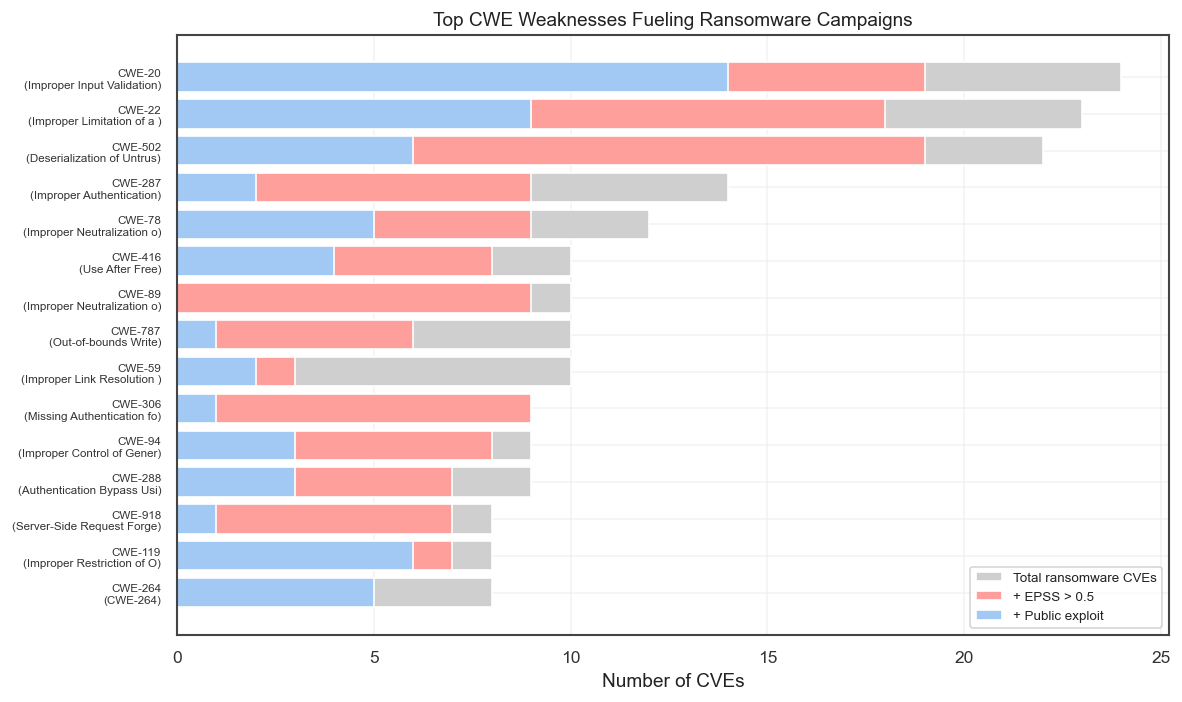


Top 5 ransomware CWEs:
  CWE-20 (Improper Input Validation): 24 CVEs
  CWE-22 (Improper Limitation of a Pathname to a Restricted Directory ('Path Traversal')): 23 CVEs
  CWE-502 (Deserialization of Untrusted Data): 22 CVEs
  CWE-287 (Improper Authentication): 14 CVEs
  CWE-78 (Improper Neutralization of Special Elements used in an OS Command ('OS Command Injection')): 12 CVEs


In [7]:
# KEV CVEs with known ransomware use
ransom = by_pred("kev-ransomware-use")
ransom_cves = set(ransom[ransom.object == "Known"].subject.unique())
print(f"KEV CVEs with known ransomware use: {len(ransom_cves)}")

# CVE → CWE
rw = by_pred("related-weakness")
ransom_cwe = rw[rw.subject.isin(ransom_cves) & rw.object.str.startswith("CWE-")]
cwe_counts = ransom_cwe.groupby("object").subject.nunique().sort_values(ascending=False)

# Enrich
epss_rows = by_pred("epss-score").copy()
epss_rows["score"] = epss_rows.object.astype(float)
high_epss = set(epss_rows[epss_rows.score > 0.5].subject)
exploit_cves = set(by_pred("exploits-cve").object)

top_n = 15
top_cwes = cwe_counts.head(top_n)

fig, ax = plt.subplots(figsize=(10, 6))
cwe_labels = []
total_vals, epss_vals, exploit_vals = [], [], []

for cwe, count in top_cwes.items():
    label = f"{cwe}\n({name_of(cwe, 25)})"
    cwe_labels.append(label)
    total_vals.append(count)
    cve_set = set(ransom_cwe[ransom_cwe.object == cwe].subject)
    epss_vals.append(len(cve_set & high_epss))
    exploit_vals.append(len(cve_set & exploit_cves))

y = np.arange(len(cwe_labels))
ax.barh(y, total_vals, color=P_GRAY, edgecolor="white", label="Total ransomware CVEs")
ax.barh(y, epss_vals, color=P_ORANGE, edgecolor="white", label="+ EPSS > 0.5")
ax.barh(y, exploit_vals, color=P_RED, edgecolor="white", label="+ Public exploit")
ax.set_yticks(y)
ax.set_yticklabels(cwe_labels, fontsize=7)
ax.set_xlabel("Number of CVEs")
ax.set_title("Top CWE Weaknesses Fueling Ransomware Campaigns")
ax.legend(fontsize=8)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 5 ransomware CWEs:")
for cwe, count in cwe_counts.head(5).items():
    label = name_of(cwe)
    print(f"  {cwe} ({label}): {count} CVEs")

## 7. High-Risk CVE Overlap (EPSS + KEV + ExploitDB)

CVEs that score high on EPSS, appear in CISA's KEV catalog, AND have a public exploit — the intersection across 3 independent risk signals.

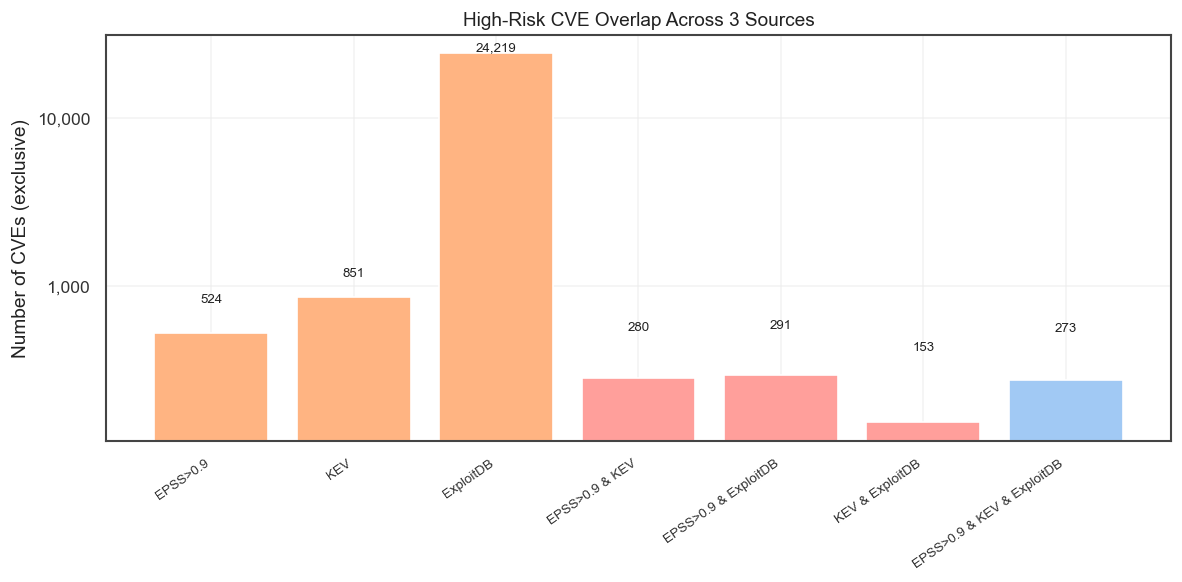

CVEs in ALL three: 273


In [8]:
epss_rows = by_pred("epss-score").copy()
epss_rows["score"] = epss_rows.object.astype(float)
high_epss = set(epss_rows[epss_rows.score > 0.9].subject.unique())

rdf = by_pred("rdf:type")
kev_cves = set(rdf[rdf.object == "KnownExploitedVulnerability"].subject.unique())
exploit_cves = set(by_pred("exploits-cve").object.unique())

sets = {"EPSS>0.9": high_epss, "KEV": kev_cves, "ExploitDB": exploit_cves}
set_labels = list(sets.keys())

combos = []
for r in range(1, len(set_labels) + 1):
    for combo in combinations(set_labels, r):
        exclusive = set.intersection(*(sets[n] for n in combo))
        for other in set_labels:
            if other not in combo:
                exclusive = exclusive - sets[other]
        combos.append((" & ".join(combo), len(exclusive)))

triple = high_epss & kev_cves & exploit_cves

fig, ax = plt.subplots(figsize=(10, 5))
labels = [c[0] for c in combos if c[1] > 0]
values = [c[1] for c in combos if c[1] > 0]
colors = [
    P_BLUE if "&" not in lab else P_RED if len(lab.split("&")) == 3 else P_ORANGE for lab in labels
]
bars = ax.bar(range(len(labels)), values, color=colors, edgecolor="white")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=8)
ax.set_ylabel("Number of CVEs (exclusive)")
ax.set_title("High-Risk CVE Overlap Across 3 Sources")
ax.set_yscale("log")
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}" if x >= 1 else ""))
for bar, val in zip(bars, values, strict=False):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(values) * 0.01,
        f"{val:,}",
        ha="center",
        va="bottom",
        fontsize=8,
    )
plt.tight_layout()
plt.show()

print(f"CVEs in ALL three: {len(triple)}")

## 8. Supply Chain Risk: Highest-Risk Open-Source Packages

Which individual open-source packages have the worst composite risk profile? Ranks packages by combining GHSA advisory count, KEV presence, EPSS scores, and public exploit availability — a 5-source traversal.

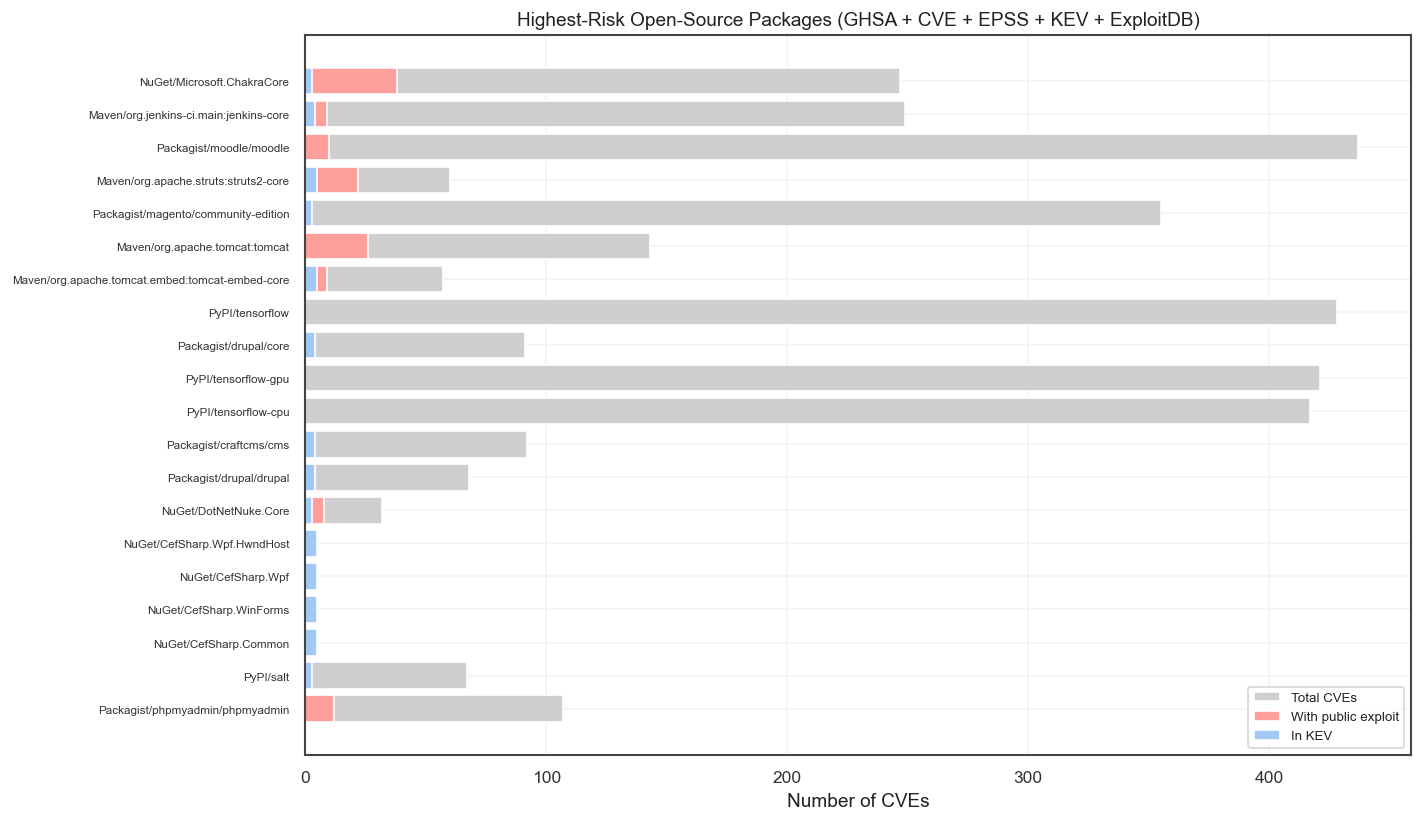

Packages with CVE links: 10,071

Top 10 highest-risk packages:
  NuGet/Microsoft.ChakraCore: 247.0 CVEs, 3 KEV, 38 exploits, max EPSS=0.909
  Maven/org.jenkins-ci.main:jenkins-core: 249.0 CVEs, 4 KEV, 9 exploits, max EPSS=0.945
  Packagist/moodle/moodle: 437.0 CVEs, 0 KEV, 10 exploits, max EPSS=0.893
  Maven/org.apache.struts:struts2-core: 60.0 CVEs, 5 KEV, 22 exploits, max EPSS=0.944
  Packagist/magento/community-edition: 355.0 CVEs, 3 KEV, 0 exploits, max EPSS=0.941
  Maven/org.apache.tomcat:tomcat: 143.0 CVEs, 0 KEV, 26 exploits, max EPSS=0.927
  Maven/org.apache.tomcat.embed:tomcat-embed-core: 57.0 CVEs, 5 KEV, 9 exploits, max EPSS=0.945
  PyPI/tensorflow: 428.0 CVEs, 0 KEV, 0 exploits, max EPSS=0.014
  Packagist/drupal/core: 91.0 CVEs, 4 KEV, 4 exploits, max EPSS=0.945
  PyPI/tensorflow-gpu: 421.0 CVEs, 0 KEV, 0 exploits, max EPSS=0.014


In [9]:
# GHSA → package → CVE → risk signals
ap = by_pred("affects-package")
ghsa_pkg = ap[ap.subject.str.startswith("GHSA-")][["subject", "object"]].rename(
    columns={"subject": "ghsa", "object": "package"}
)

rc = by_pred("related-cve")
ghsa_cve = rc[rc.subject.str.startswith("GHSA-")][["subject", "object"]].rename(
    columns={"subject": "ghsa", "object": "cve"}
)

pkg_cve = ghsa_pkg.merge(ghsa_cve, on="ghsa")[["package", "cve"]].drop_duplicates()

rdf = by_pred("rdf:type")
kev_set = set(rdf[rdf.object == "KnownExploitedVulnerability"].subject)
exploit_set = set(by_pred("exploits-cve").object)
epss_df = by_pred("epss-score")[["subject", "object"]].rename(
    columns={"subject": "cve", "object": "epss"}
)
epss_df["epss"] = epss_df["epss"].astype(float)

pkg_risk = pkg_cve.merge(epss_df[["cve", "epss"]], on="cve", how="left").fillna({"epss": 0})
pkg_risk["in_kev"] = pkg_risk.cve.isin(kev_set)
pkg_risk["has_exploit"] = pkg_risk.cve.isin(exploit_set)

pkg_agg = pkg_risk.groupby("package").agg(
    cve_count=("cve", "nunique"),
    kev_count=("in_kev", "sum"),
    exploit_count=("has_exploit", "sum"),
    max_epss=("epss", "max"),
    mean_epss=("epss", "mean"),
)
pkg_agg["risk_score"] = (
    pkg_agg.cve_count * 1
    + pkg_agg.kev_count * 50
    + pkg_agg.exploit_count * 10
    + pkg_agg.max_epss * 100
)
pkg_agg = pkg_agg.sort_values("risk_score", ascending=False)

top = pkg_agg.head(20)

fig, ax = plt.subplots(figsize=(12, 7))
y = np.arange(len(top))

ax.barh(y, top.cve_count, color=P_GRAY, edgecolor="white", label="Total CVEs")
ax.barh(y, top.exploit_count, color=P_ORANGE, edgecolor="white", label="With public exploit")
ax.barh(y, top.kev_count, color=P_RED, edgecolor="white", label="In KEV")

ax.set_yticks(y)
ax.set_yticklabels(top.index, fontsize=7)
ax.set_xlabel("Number of CVEs")
ax.set_title("Highest-Risk Open-Source Packages (GHSA + CVE + EPSS + KEV + ExploitDB)")
ax.legend(fontsize=8, loc="lower right")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"Packages with CVE links: {len(pkg_agg):,}")
print("\nTop 10 highest-risk packages:")
for pkg, row in top.head(10).iterrows():
    print(
        f"  {pkg}: {row.cve_count} CVEs, {int(row.kev_count)} KEV, "
        f"{int(row.exploit_count)} exploits, max EPSS={row.max_epss:.3f}"
    )

## 9. Platform-Specific Attack Surface

Cross-references platform data from ATT&CK techniques, Sigma log sources, and ExploitDB to show per-platform threat landscape and detection readiness.

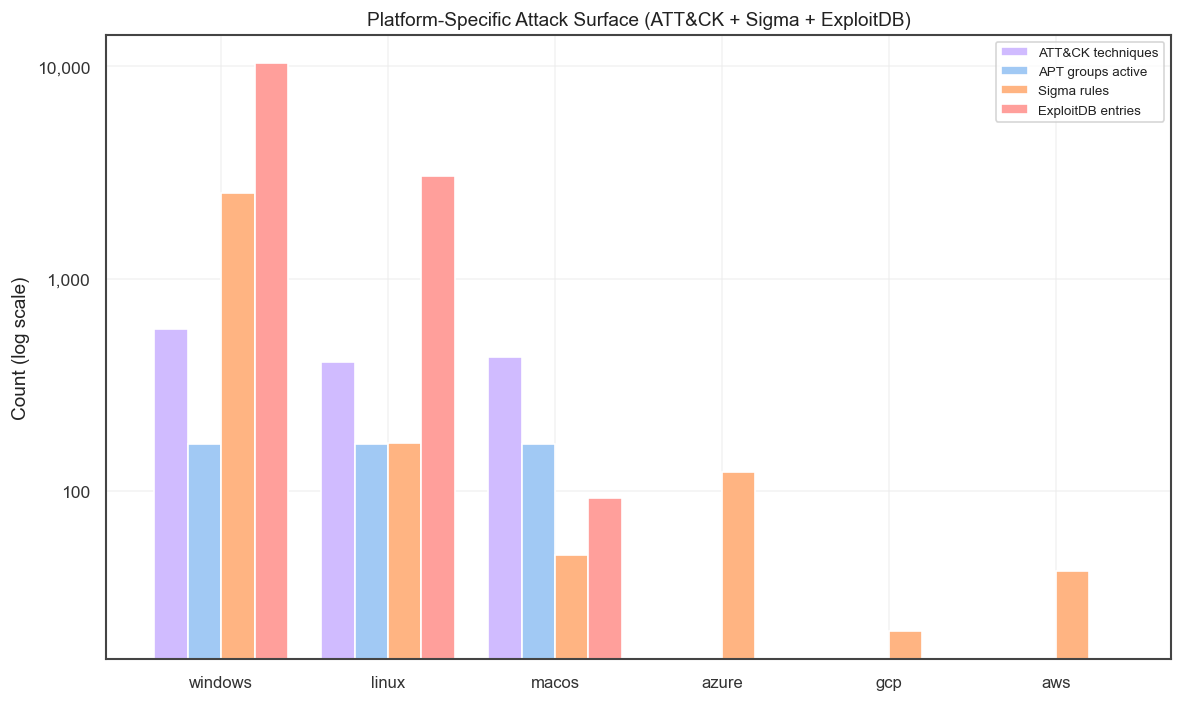

Platform attack surface summary:
  windows   : 577 techniques, 166 groups, 2517 Sigma, 10305 exploits (Sigma/technique ratio: 4.4)
  linux     : 407 techniques, 166 groups,  169 Sigma,  3041 exploits (Sigma/technique ratio: 0.4)
  macos     : 430 techniques, 166 groups,   50 Sigma,    93 exploits (Sigma/technique ratio: 0.1)
  azure     :   0 techniques,   0 groups,  123 Sigma,     0 exploits (Sigma/technique ratio: 0.0)
  gcp       :   0 techniques,   0 groups,   22 Sigma,     0 exploits (Sigma/technique ratio: 0.0)
  aws       :   0 techniques,   0 groups,   42 Sigma,     0 exploits (Sigma/technique ratio: 0.0)


In [10]:
# ATT&CK techniques per platform
plat = by_pred("platform")
attack_plat = plat[plat.subject.str.startswith("T")][["subject", "object"]].rename(
    columns={"subject": "technique", "object": "platform"}
)

platform_map = {
    "Windows": "windows",
    "Linux": "linux",
    "macOS": "macos",
    "Azure AD": "azure",
    "Google Workspace": "gcp",
}
attack_plat["platform_norm"] = attack_plat.platform.map(platform_map).fillna(
    attack_plat.platform.str.lower()
)

lp = by_pred("logsource-product")[["subject", "object"]].rename(
    columns={"subject": "sigma", "object": "platform_norm"}
)
edb_plat = plat[plat.subject.str.startswith("EDB-")][["subject", "object"]].rename(
    columns={"subject": "edb", "object": "platform_norm"}
)

uses = by_pred("uses")
group_tech = uses[uses.subject.str.startswith("G") & uses.object.str.startswith("T")]

platforms = ["windows", "linux", "macos", "azure", "gcp", "aws"]
rows = []
for p in platforms:
    techs = set(attack_plat[attack_plat.platform_norm == p].technique)
    sigma_count = lp[lp.platform_norm == p].sigma.nunique()
    edb_count = edb_plat[edb_plat.platform_norm == p].edb.nunique()
    groups_active = group_tech[group_tech.object.isin(techs)].subject.nunique() if techs else 0
    rows.append(
        {
            "platform": p,
            "techniques": len(techs),
            "sigma_rules": sigma_count,
            "exploitdb": edb_count,
            "apt_groups": groups_active,
        }
    )

pdf = pd.DataFrame(rows).set_index("platform")

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(pdf))
w = 0.2

ax.bar(x - 1.5 * w, pdf.techniques, w, color=P_PURPLE, edgecolor="white", label="ATT&CK techniques")
ax.bar(x - 0.5 * w, pdf.apt_groups, w, color=P_RED, edgecolor="white", label="APT groups active")
ax.bar(x + 0.5 * w, pdf.sigma_rules, w, color=P_BLUE, edgecolor="white", label="Sigma rules")
ax.bar(x + 1.5 * w, pdf.exploitdb, w, color=P_ORANGE, edgecolor="white", label="ExploitDB entries")

ax.set_xticks(x)
ax.set_xticklabels(pdf.index, fontsize=10)
ax.set_ylabel("Count (log scale)")
ax.set_yscale("log")
ax.set_title("Platform-Specific Attack Surface (ATT&CK + Sigma + ExploitDB)")
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}" if x >= 1 else ""))
plt.tight_layout()
plt.show()

print("Platform attack surface summary:")
for p, row in pdf.iterrows():
    ratio = row.sigma_rules / row.techniques if row.techniques > 0 else 0
    print(
        f"  {p:10s}: {row.techniques:3.0f} techniques, {row.apt_groups:3.0f} groups, "
        f"{row.sigma_rules:4.0f} Sigma, {row.exploitdb:5.0f} exploits "
        f"(Sigma/technique ratio: {ratio:.1f})"
    )

## 10. Vendor Vulnerability Landscape

Top vendors by CVE count, with stacked enrichment showing how many of their CVEs are in KEV, have high EPSS, or have public exploits.

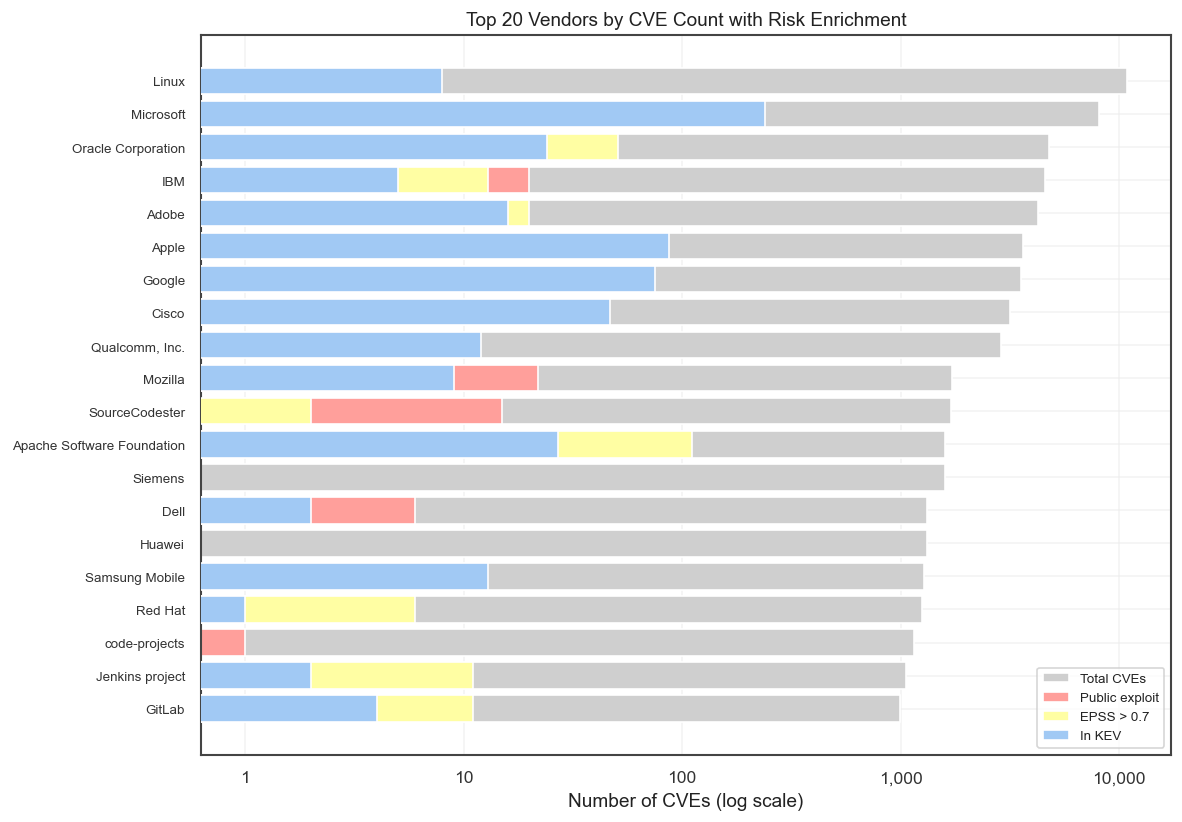

Total vendors (excl. n/a, Unknown): 21902

Highest KEV density:
  Linux: 8 KEV / 10852 total (0.1%)
  Microsoft: 239 KEV / 8089 total (3.0%)
  Oracle Corporation: 24 KEV / 4784 total (0.5%)
  IBM: 5 KEV / 4602 total (0.1%)
  Adobe: 16 KEV / 4235 total (0.4%)
  Apple: 87 KEV / 3641 total (2.4%)
  Google: 75 KEV / 3560 total (2.1%)
  Cisco: 47 KEV / 3159 total (1.5%)
  Qualcomm, Inc.: 12 KEV / 2885 total (0.4%)
  Mozilla: 9 KEV / 1713 total (0.5%)


In [11]:
# CVE → vendor
vendor_rows = by_pred("vendor")
cve_vendor = vendor_rows[vendor_rows.subject.str.startswith("CVE-")]
cve_vendor = cve_vendor[~cve_vendor.object.isin(["n/a", "Unknown"])]
vendor_counts = cve_vendor.groupby("object").subject.nunique().sort_values(ascending=False)

rdf = by_pred("rdf:type")
kev_cves = set(rdf[rdf.object == "KnownExploitedVulnerability"].subject)
epss_rows = by_pred("epss-score").copy()
epss_rows["score"] = epss_rows.object.astype(float)
high_epss = set(epss_rows[epss_rows.score > 0.7].subject)
exploit_cves = set(by_pred("exploits-cve").object)

top_n = 20
top_vendors = vendor_counts.head(top_n)

fig, ax = plt.subplots(figsize=(10, 7))
labels, totals, kev_vals, epss_vals, exploit_vals = [], [], [], [], []

for vendor, count in top_vendors.items():
    labels.append(vendor)
    totals.append(count)
    vendor_cve_set = set(cve_vendor[cve_vendor.object == vendor].subject)
    kev_vals.append(len(vendor_cve_set & kev_cves))
    epss_vals.append(len(vendor_cve_set & high_epss))
    exploit_vals.append(len(vendor_cve_set & exploit_cves))

y = np.arange(len(labels))
ax.barh(y, totals, color=P_GRAY, edgecolor="white", label="Total CVEs", zorder=1)
ax.barh(y, exploit_vals, color=P_ORANGE, edgecolor="white", label="Public exploit", zorder=2)
ax.barh(y, epss_vals, color=P_YELLOW, edgecolor="white", label="EPSS > 0.7", zorder=3)
ax.barh(y, kev_vals, color=P_RED, edgecolor="white", label="In KEV", zorder=4)

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("Number of CVEs (log scale)")
ax.set_xscale("log")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}" if x >= 1 else ""))
ax.set_title("Top 20 Vendors by CVE Count with Risk Enrichment")
ax.legend(fontsize=8, loc="lower right")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"Total vendors (excl. n/a, Unknown): {vendor_counts.shape[0]}")
print("\nHighest KEV density:")
for vendor in labels[:10]:
    vc = set(cve_vendor[cve_vendor.object == vendor].subject)
    k = len(vc & kev_cves)
    if k > 0:
        print(f"  {vendor}: {k} KEV / {len(vc)} total ({100 * k / len(vc):.1f}%)")

## 11. CWE Bridge Nodes: GHSA → ATT&CK

Which CWEs serve as the busiest bridges connecting GitHub Security Advisories to ATT&CK techniques? Traverses GHSA → CVE → CWE → CAPEC → ATT&CK technique.

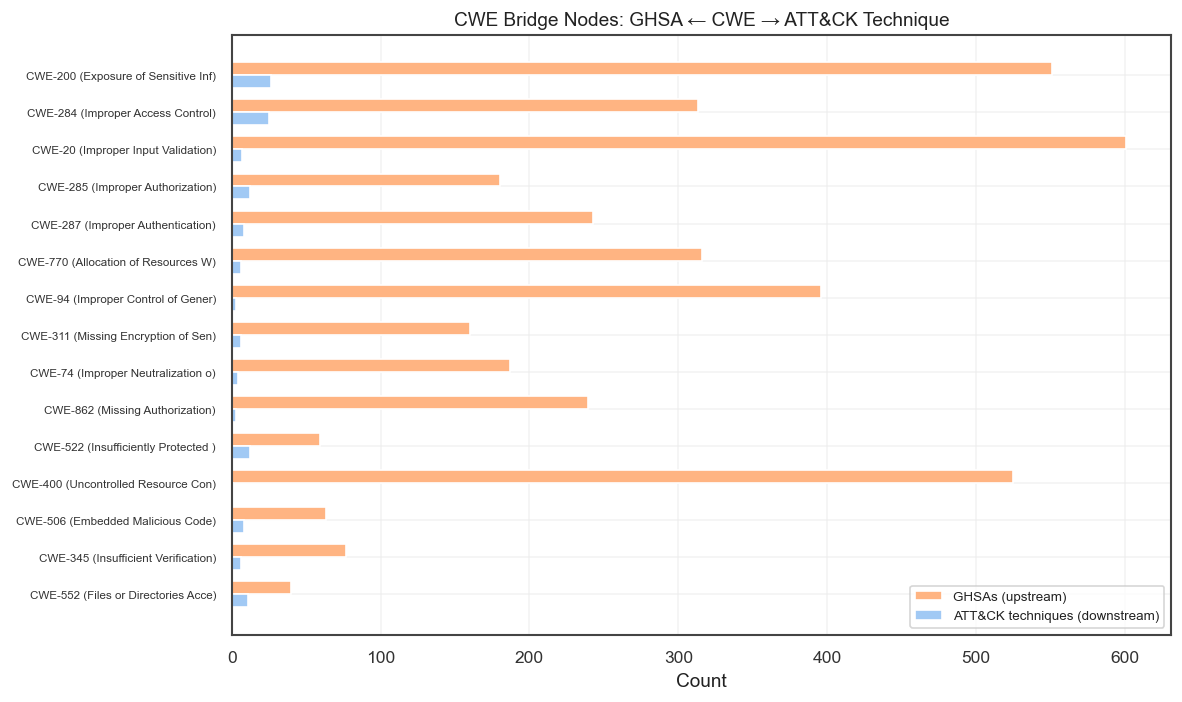

Top bridge CWEs (connecting most GHSAs to most ATT&CK techniques):
  CWE-200 (Exposure of Sensitive Information to an Unauthorized Actor): 551 GHSAs → 26 techniques
  CWE-284 (Improper Access Control): 313 GHSAs → 25 techniques
  CWE-20 (Improper Input Validation): 601 GHSAs → 7 techniques
  CWE-285 (Improper Authorization): 180 GHSAs → 12 techniques
  CWE-287 (Improper Authentication): 243 GHSAs → 8 techniques


In [12]:
# GHSA → CVE
rc = by_pred("related-cve")
ghsa_cve = rc[rc.subject.str.startswith("GHSA-")][["subject", "object"]].rename(
    columns={"subject": "ghsa", "object": "cve"}
)

# CVE → CWE
rw = by_pred("related-weakness")
cve_cwe = rw[rw.subject.str.startswith("CVE-") & rw.object.str.startswith("CWE-")][
    ["subject", "object"]
].rename(columns={"subject": "cve", "object": "cwe"})

# CWE → CAPEC → technique
cwe_capec = by_pred("related-attack-pattern")[["subject", "object"]].rename(
    columns={"subject": "cwe", "object": "capec"}
)
capec_tech = by_pred("maps-to-technique")[["subject", "object"]].rename(
    columns={"subject": "capec", "object": "technique"}
)

ghsa_side = ghsa_cve.merge(cve_cwe, on="cve")
ghsa_per_cwe = ghsa_side.groupby("cwe").ghsa.nunique().rename("ghsa_count")

attack_side = cve_cwe.merge(cwe_capec, on="cwe").merge(capec_tech, on="capec")
tech_per_cwe = attack_side.groupby("cwe").technique.nunique().rename("technique_count")

bridge = pd.DataFrame({"ghsa_count": ghsa_per_cwe, "technique_count": tech_per_cwe}).dropna()
bridge = bridge[(bridge.ghsa_count > 0) & (bridge.technique_count > 0)]
bridge["bridge_score"] = bridge.ghsa_count * bridge.technique_count
bridge = bridge.sort_values("bridge_score", ascending=False).head(15)

fig, ax1 = plt.subplots(figsize=(10, 6))
y = np.arange(len(bridge))
w = 0.35

labels = []
for cwe in bridge.index:
    label = f"{cwe} ({name_of(cwe, 25)})"
    labels.append(label)

ax1.barh(y - w / 2, bridge.ghsa_count, w, color=P_BLUE, edgecolor="white", label="GHSAs (upstream)")
ax1.barh(
    y + w / 2,
    bridge.technique_count,
    w,
    color=P_RED,
    edgecolor="white",
    label="ATT&CK techniques (downstream)",
)
ax1.set_yticks(y)
ax1.set_yticklabels(labels, fontsize=7)
ax1.set_xlabel("Count")
ax1.set_title("CWE Bridge Nodes: GHSA ← CWE → ATT&CK Technique")
ax1.legend(fontsize=8)
ax1.invert_yaxis()
plt.tight_layout()
plt.show()

print("Top bridge CWEs (connecting most GHSAs to most ATT&CK techniques):")
for cwe in bridge.head(5).index:
    label = name_of(cwe)
    ghsas = int(bridge.loc[cwe, "ghsa_count"])
    techs = int(bridge.loc[cwe, "technique_count"])
    print(f"  {cwe} ({label}): {ghsas} GHSAs → {techs} techniques")

## 12. CWE Weakness Hierarchy — Where Vulnerabilities Cluster

Aggregates CVEs up the CWE `child-of` tree to find which root weakness families contain the most real-world vulnerabilities.

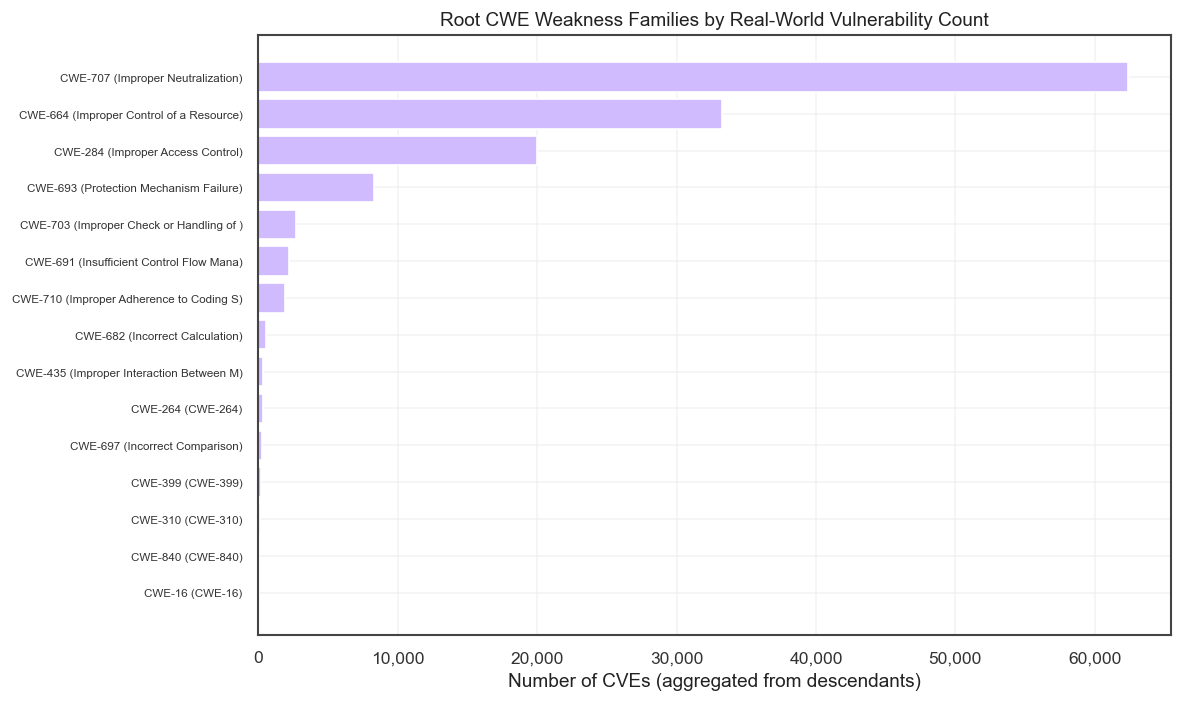

Total CWEs with CVE links: 750
Root CWE families: 55

Top 5 root families:
  CWE-707 (Improper Neutralization): 62,344 CVEs
  CWE-664 (Improper Control of a Resource Through its Lifetime): 33,258 CVEs
  CWE-284 (Improper Access Control): 19,955 CVEs
  CWE-693 (Protection Mechanism Failure): 8,254 CVEs
  CWE-703 (Improper Check or Handling of Exceptional Conditions): 2,672 CVEs


In [13]:
# Build CWE parent mapping from child-of predicate
child_of = by_pred("child-of")
cwe_parent = dict(zip(child_of.subject, child_of.object, strict=False))


def find_root(cwe, parents, max_depth=20):
    visited = set()
    current = cwe
    for _ in range(max_depth):
        if current in visited or current not in parents:
            return current
        visited.add(current)
        current = parents[current]
    return current


rw = by_pred("related-weakness")
cve_cwe = rw[rw.subject.str.startswith("CVE-") & rw.object.str.startswith("CWE-")]
cwe_cve_count = cve_cwe.groupby("object").subject.nunique()

root_counts: dict[str, int] = {}
for cwe, count in cwe_cve_count.items():
    root = find_root(cwe, cwe_parent)
    root_counts[root] = root_counts.get(root, 0) + count

root_df = pd.DataFrame([{"cwe": k, "cve_count": v} for k, v in root_counts.items()]).sort_values(
    "cve_count", ascending=False
)

top_n = 15
top_roots = root_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 6))
labels = []
for _, row in top_roots.iterrows():
    label = f"{row.cwe} ({name_of(row.cwe, 30)})"
    labels.append(label)

y = np.arange(len(labels))
ax.barh(y, top_roots.cve_count.values, color=P_PURPLE, edgecolor="white")
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=7)
ax.set_xlabel("Number of CVEs (aggregated from descendants)")
ax.set_title("Root CWE Weakness Families by Real-World Vulnerability Count")
ax.invert_yaxis()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

print(f"Total CWEs with CVE links: {len(cwe_cve_count)}")
print(f"Root CWE families: {len(root_counts)}")
print("\nTop 5 root families:")
for _, row in top_roots.head(5).iterrows():
    label = name_of(row.cwe)
    print(f"  {row.cwe} ({label}): {row.cve_count:,} CVEs")

## 13. CWE Consequence Analysis — What Weakness Properties Produce the Worst Outcomes?

Correlates CWE consequence scopes (Confidentiality, Integrity, Availability) and impacts with real-world CVE severity data to reveal which weakness properties are most dangerous.

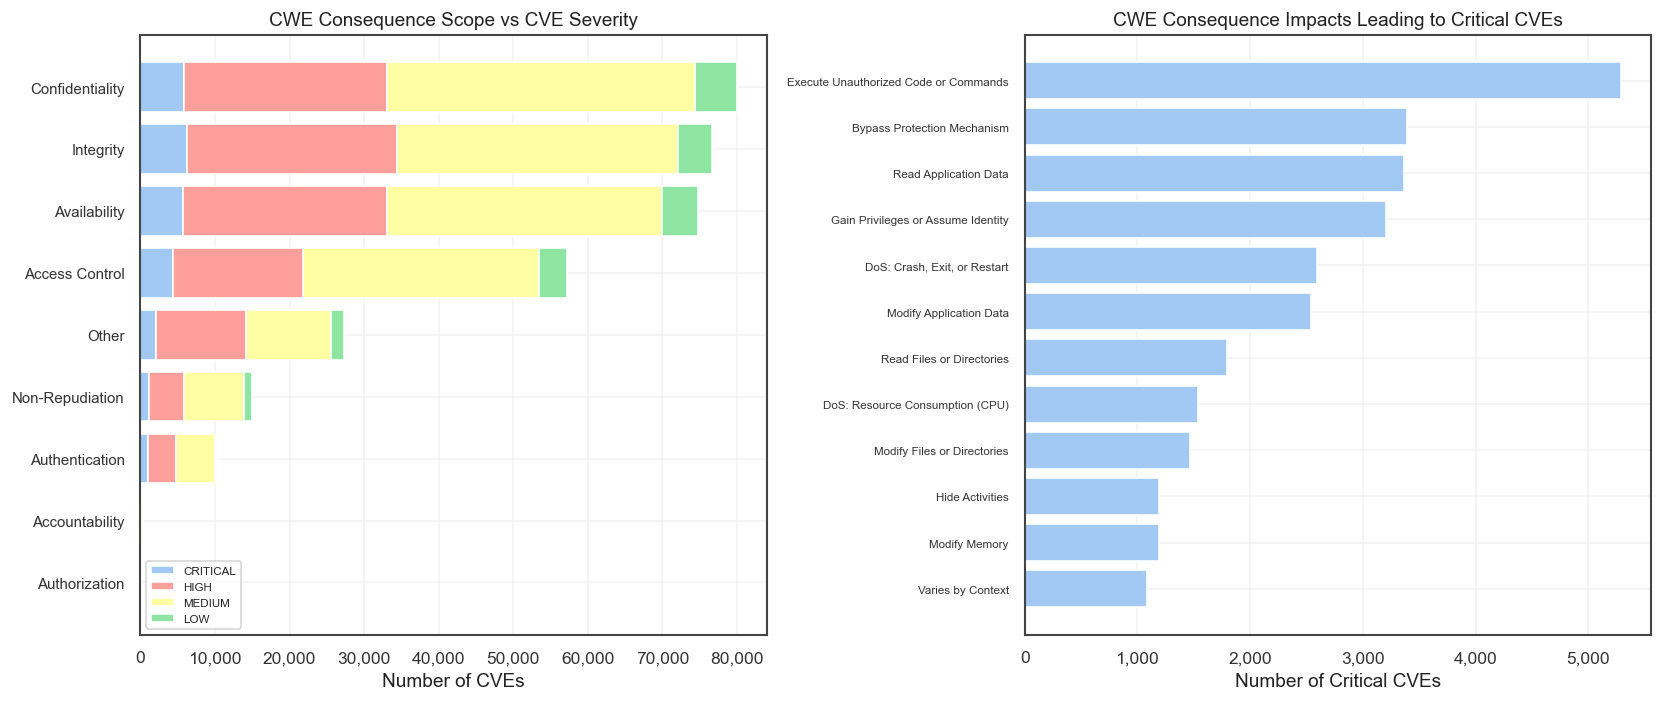

CWEs with consequence data: 944 (scope), 944 (impact)
CVEs linked to consequence-annotated CWEs: 94,206

Critical CVE rate by consequence scope:
  Authorization: 8 / 221 (3.6% critical)
  Accountability: 11 / 314 (3.5% critical)
  Authentication: 966 / 10,107 (9.6% critical)
  Non-Repudiation: 1,202 / 14,895 (8.1% critical)
  Other: 2,151 / 27,306 (7.9% critical)
  Access Control: 4,392 / 57,214 (7.7% critical)
  Availability: 5,717 / 74,807 (7.6% critical)
  Integrity: 6,306 / 76,616 (8.2% critical)
  Confidentiality: 5,874 / 79,999 (7.3% critical)


In [14]:
# CWE consequence scopes and impacts
cs = by_pred("consequence-scope")[["subject", "object"]].rename(
    columns={"subject": "cwe", "object": "scope"}
)
cs = cs[cs.cwe.str.startswith("CWE-")]

ci = by_pred("consequence-impact")[["subject", "object"]].rename(
    columns={"subject": "cwe", "object": "impact"}
)
ci = ci[ci.cwe.str.startswith("CWE-")]

# CWE → CVE → severity
rw = by_pred("related-weakness")
cve_cwe = rw[rw.subject.str.startswith("CVE-") & rw.object.str.startswith("CWE-")][
    ["subject", "object"]
].rename(columns={"subject": "cve", "object": "cwe"})
sev = by_pred("cvss-severity")[["subject", "object"]].rename(
    columns={"subject": "cve", "object": "severity"}
)

cve_sev = cve_cwe.merge(sev, on="cve")

scope_sev = cs.merge(cve_sev, on="cwe")
scope_sev_counts = scope_sev.groupby(["scope", "severity"]).cve.nunique().unstack(fill_value=0)

# CVSS uses "MEDIUM" (vs GHSA's "MODERATE" in cell 14)
sev_order = ["CRITICAL", "HIGH", "MEDIUM", "LOW"]
sev_colors = {"CRITICAL": P_RED, "HIGH": P_ORANGE, "MEDIUM": P_YELLOW, "LOW": P_GREEN}
plot_sevs = [s for s in sev_order if s in scope_sev_counts.columns]
scope_sev_counts = scope_sev_counts[plot_sevs]
scope_sev_counts["total"] = scope_sev_counts.sum(axis=1)
scope_sev_counts = scope_sev_counts.sort_values("total", ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

y = np.arange(len(scope_sev_counts))
left = np.zeros(len(scope_sev_counts))
for s in plot_sevs:
    if s in scope_sev_counts.columns:
        vals = scope_sev_counts[s].values
        ax1.barh(y, vals, left=left, color=sev_colors[s], edgecolor="white", label=s)
        left += vals
ax1.set_yticks(y)
ax1.set_yticklabels(scope_sev_counts.index, fontsize=9)
ax1.set_xlabel("Number of CVEs")
ax1.set_title("CWE Consequence Scope vs CVE Severity")
ax1.legend(fontsize=7)
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

impact_sev = ci.merge(cve_sev, on="cwe")
impact_crit = impact_sev[impact_sev.severity == "CRITICAL"].groupby("impact").cve.nunique()
impact_crit = impact_crit.sort_values(ascending=True).tail(12)

ax2.barh(range(len(impact_crit)), impact_crit.values, color=P_RED, edgecolor="white")
ax2.set_yticks(range(len(impact_crit)))
ax2.set_yticklabels(impact_crit.index, fontsize=7)
ax2.set_xlabel("Number of Critical CVEs")
ax2.set_title("CWE Consequence Impacts Leading to Critical CVEs")
ax2.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.show()

print(f"CWEs with consequence data: {cs.cwe.nunique()} (scope), {ci.cwe.nunique()} (impact)")
print(f"CVEs linked to consequence-annotated CWEs: {scope_sev.cve.nunique():,}")
print("\nCritical CVE rate by consequence scope:")
for scope in scope_sev_counts.index:
    total = scope_sev_counts.loc[scope, "total"]
    crit = scope_sev_counts.loc[scope, "CRITICAL"] if "CRITICAL" in scope_sev_counts.columns else 0
    print(f"  {scope}: {crit:,} / {total:,} ({100 * crit / total:.1f}% critical)")

## 14. GHSA Package Ecosystem Risk

Advisory severity distribution by open-source package ecosystem (npm, pip, maven, Go, etc.).

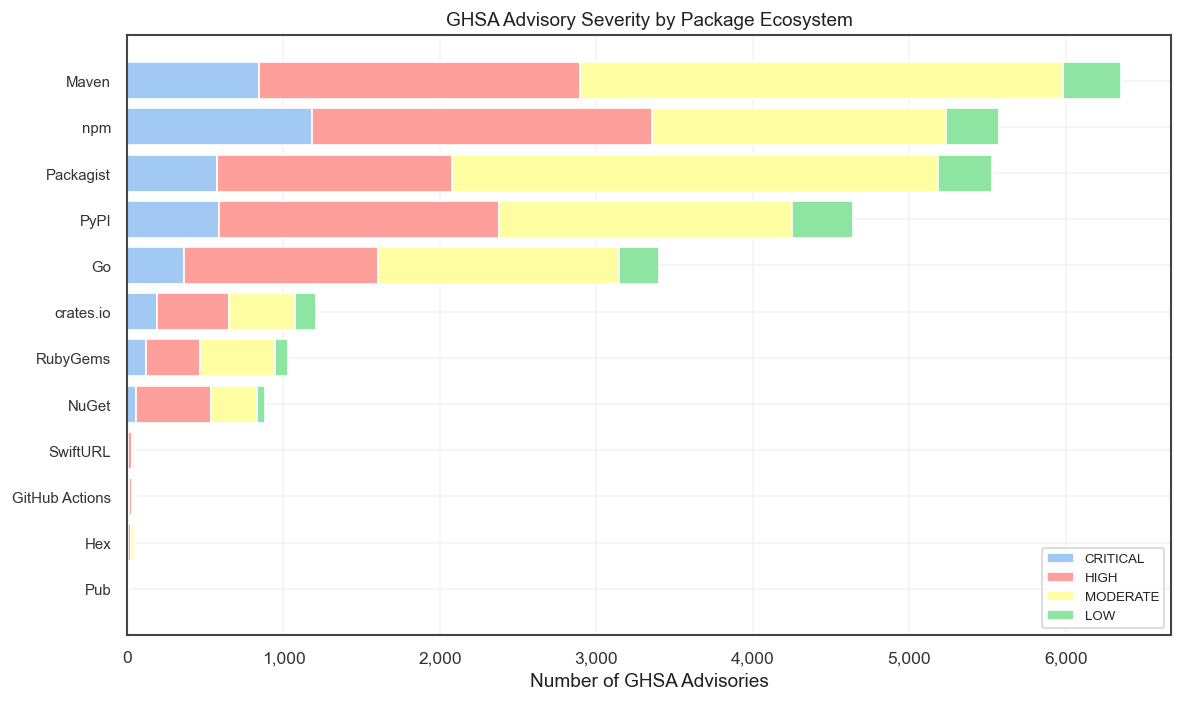

Total GHSA advisories with package+severity: 28384
Ecosystems: 12

Top ecosystems by critical advisories:
  npm: 1183 critical
  Maven: 843 critical
  PyPI: 589 critical
  Packagist: 573 critical
  Go: 365 critical


In [15]:
# GHSA → affects-package → ecosystem extraction
ap = by_pred("affects-package")
ghsa_pkg = ap[ap.subject.str.startswith("GHSA-")].copy()

ghsa_pkg["ecosystem"] = ghsa_pkg.object.str.split("/", n=1).str[0]

sev = by_pred("severity")
ghsa_sev = sev[sev.subject.str.startswith("GHSA-")]

ghsa_eco_sev = ghsa_pkg[["subject", "ecosystem"]].merge(
    ghsa_sev[["subject", "object"]].rename(columns={"object": "severity"}), on="subject"
)

eco_sev = ghsa_eco_sev.groupby(["ecosystem", "severity"]).subject.nunique().unstack(fill_value=0)

eco_totals = eco_sev.sum(axis=1).sort_values(ascending=False)
top_ecos = eco_totals.head(12).index
eco_sev = eco_sev.loc[top_ecos]

# GHSA uses "MODERATE" (vs CVSS's "MEDIUM" in cell 13)
sev_order = ["CRITICAL", "HIGH", "MODERATE", "LOW"]
sev_colors = {"CRITICAL": P_RED, "HIGH": P_ORANGE, "MODERATE": P_YELLOW, "LOW": P_GREEN}
plot_sevs = [s for s in sev_order if s in eco_sev.columns]

fig, ax = plt.subplots(figsize=(10, 6))
bottom = np.zeros(len(eco_sev))
for sev_level in plot_sevs:
    vals = eco_sev[sev_level].values
    ax.barh(
        np.arange(len(eco_sev)),
        vals,
        left=bottom,
        color=sev_colors[sev_level],
        edgecolor="white",
        label=sev_level,
    )
    bottom += vals

ax.set_yticks(np.arange(len(eco_sev)))
ax.set_yticklabels(eco_sev.index, fontsize=9)
ax.set_xlabel("Number of GHSA Advisories")
ax.set_title("GHSA Advisory Severity by Package Ecosystem")
ax.legend(fontsize=8, loc="lower right")
ax.invert_yaxis()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

print(f"Total GHSA advisories with package+severity: {ghsa_eco_sev.subject.nunique()}")
print(f"Ecosystems: {len(eco_totals)}")
print("\nTop ecosystems by critical advisories:")
if "CRITICAL" in eco_sev.columns:
    for eco in eco_sev.sort_values("CRITICAL", ascending=False).head(5).index:
        print(f"  {eco}: {eco_sev.loc[eco, 'CRITICAL']} critical")

## 15. ATLAS ↔ ATT&CK Bridge — ML Threats Meeting Traditional APTs

Which ATLAS (ML/AI) techniques overlap with ATT&CK techniques used by known APT groups? Text output — the dataset is small (~33 relationships).

In [16]:
# ATLAS technique → related ATT&CK technique
rat = by_pred("related-attack-technique")
atlas_attack = rat[rat.subject.str.startswith("AML.")][["subject", "object"]].rename(
    columns={"subject": "atlas", "object": "attack_tech"}
)

# ATT&CK technique → groups using it
uses = by_pred("uses")
group_tech = uses[uses.subject.str.startswith("G") & uses.object.str.startswith("T")]

# Join: which ATLAS techniques connect to group-used ATT&CK techniques
joined = atlas_attack.merge(
    group_tech[["subject", "object"]].rename(columns={"subject": "group", "object": "attack_tech"}),
    on="attack_tech",
)


print(f"ATLAS ↔ ATT&CK relationships: {len(atlas_attack)}")
print(f"ATLAS techniques with APT group overlap: {joined.atlas.nunique()}")
print(f"APT groups reachable via ATLAS bridge: {joined.group.nunique()}")
print()

# Show ATLAS techniques and which groups they connect to
atlas_groups = (
    joined.groupby("atlas")
    .agg(attack_techs=("attack_tech", "nunique"), groups=("group", "nunique"))
    .sort_values("groups", ascending=False)
)

print("ATLAS techniques with most APT group overlap:")
for atlas_id, row in atlas_groups.head(10).iterrows():
    label = name_of(atlas_id)
    print(f"  {atlas_id} ({label}): {row.attack_techs} ATT&CK techniques → {row.groups} groups")

ATLAS ↔ ATT&CK relationships: 33
ATLAS techniques with APT group overlap: 29
APT groups reachable via ATLAS bridge: 139

ATLAS techniques with most APT group overlap:
  AML.T0016.001 (Software Tools): 1 ATT&CK techniques → 79 groups
  AML.T0012 (Valid Accounts): 1 ATT&CK techniques → 44 groups
  AML.T0037 (Data from Local System): 1 ATT&CK techniques → 43 groups
  AML.T0049 (Exploit Public-Facing Application): 1 ATT&CK techniques → 42 groups
  AML.T0089 (Process Discovery): 1 ATT&CK techniques → 40 groups
  AML.T0008.002 (Domains): 1 ATT&CK techniques → 40 groups
  AML.T0078 (Drive-by Compromise): 1 ATT&CK techniques → 31 groups
  AML.T0074 (Masquerading): 1 ATT&CK techniques → 20 groups
  AML.T0050 (Command and Scripting Interpreter): 1 ATT&CK techniques → 17 groups
  AML.T0090 (OS Credential Dumping): 1 ATT&CK techniques → 13 groups


## 16. Sigma Rule Maturity vs Threat Coverage

Are production-ready (stable) Sigma rules covering the most dangerous techniques? Text output — only 3 maturity levels.

In [17]:
# Sigma rule → status (stable/test/experimental)
status = by_pred("status")
sigma_status = status[
    ~status.subject.str.startswith("CVE-") & ~status.subject.str.startswith("CWE-")
]

# Sigma rule → technique
dt = by_pred("detects-technique")
sigma_tech = dt[~dt.subject.str.startswith("CAR-")][["subject", "object"]].rename(
    columns={"subject": "sigma", "object": "technique"}
)

# Group → technique
uses = by_pred("uses")
group_tech = uses[uses.subject.str.startswith("G") & uses.object.str.startswith("T")]
apt_techniques = set(group_tech.object.unique())

# Join sigma with status
sigma_with_status = sigma_tech.merge(
    sigma_status[["subject", "object"]].rename(columns={"subject": "sigma", "object": "maturity"}),
    on="sigma",
)

print(f"Sigma rules with technique mappings: {sigma_tech.sigma.nunique()}")
print(f"Sigma rules with status info: {sigma_with_status.sigma.nunique()}")
print(f"ATT&CK techniques used by APT groups: {len(apt_techniques)}")
print()

# Per maturity level: how many rules, how many techniques, how many APT-used techniques
for maturity in ["stable", "test", "experimental"]:
    subset = sigma_with_status[sigma_with_status.maturity == maturity]
    rules = subset.sigma.nunique()
    techs = set(subset.technique.unique())
    apt_covered = techs & apt_techniques
    pct = 100 * len(apt_covered) / len(apt_techniques)
    print(
        f"  {maturity:14s}: {rules:4d} rules → {len(techs):3d} techniques "
        f"({len(apt_covered):3d} APT-used, {pct:.0f}% of all APT techniques)"
    )

# Which APT techniques have NO sigma coverage at all?
all_sigma_techs = set(sigma_tech.technique.unique())
uncovered = apt_techniques - all_sigma_techs
print(f"\nAPT techniques with zero Sigma coverage: {len(uncovered)} / {len(apt_techniques)}")
if uncovered:
    print("Sample uncovered:")
    for tech in sorted(uncovered)[:8]:
        label = name_of(tech)
        print(f"  {tech} ({label})")

Sigma rules with technique mappings: 2804
Sigma rules with status info: 2804
ATT&CK techniques used by APT groups: 521

  stable        :   82 rules →  58 techniques ( 53 APT-used, 10% of all APT techniques)
  test          : 2528 rules → 361 techniques (289 APT-used, 55% of all APT techniques)
  experimental  :  194 rules → 116 techniques (105 APT-used, 20% of all APT techniques)

APT techniques with zero Sigma coverage: 224 / 521
Sample uncovered:
  T0807 (Command-Line Interface)
  T0817 (Drive-by Compromise)
  T0819 (Exploit Public-Facing Application)
  T0852 (Screen Capture)
  T0853 (Scripting)
  T0859 (Valid Accounts)
  T0862 (Supply Chain Compromise)
  T0865 (Spearphishing Attachment)
